In [40]:
import pandas as pd
import requests
from tqdm import tqdm 

In [41]:
competition_id = 43
season_id = 106

# URL de partidos
matches_url = f"https://raw.githubusercontent.com/statsbomb/open-data/master/data/matches/{competition_id}/{season_id}.json"

# Obtener partidos
matches = requests.get(matches_url).json()

# Convertir a DataFrame
df_matches = pd.json_normalize(matches)

print(df_matches.head())
print(f"Total matches: {len(df_matches)}")

   match_id  match_date      kick_off  home_score  away_score match_status  \
0   3857256  2022-12-02  21:00:00.000           2           3    available   
1   3869151  2022-12-03  21:00:00.000           2           1    available   
2   3857257  2022-11-30  17:00:00.000           1           0    available   
3   3857258  2022-11-24  21:00:00.000           2           0    available   
4   3857288  2022-11-26  12:00:00.000           0           1    available   

  match_status_360                last_updated            last_updated_360  \
0        available  2023-02-17T23:45:15.306706  2023-04-26T23:49:58.956186   
1        available  2023-07-30T07:46:05.382784  2023-07-30T07:48:51.865595   
2        available  2023-04-28T17:13:10.958725  2023-06-20T11:04:37.638969   
3        available  2023-06-24T17:17:27.911026  2023-07-11T14:56:31.096588   
4        available  2023-02-28T21:25:20.888552  2023-04-27T00:30:07.835815   

   match_week  ...  competition_stage.id competition_stage.nam

In [36]:
df_matches.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage.id,competition_stage.name,stadium.id,stadium.name,stadium.country.id,stadium.country.name,referee.id,referee.name,referee.country.id,referee.country.name
0,3857256,2022-12-02,21:00:00.000,2,3,available,available,2023-02-17T23:45:15.306706,2023-04-26T23:49:58.956186,3,...,10,Group Stage,1001115,Stadium 974,185,Qatar,1121.0,Fernando Andrés Rapallini,11.0,Argentina
1,3869151,2022-12-03,21:00:00.000,2,1,available,available,2023-07-30T07:46:05.382784,2023-07-30T07:48:51.865595,4,...,33,Round of 16,1000793,Ahmad bin Ali Stadium,185,Qatar,367.0,Szymon Marciniak,182.0,Poland
2,3857257,2022-11-30,17:00:00.000,1,0,available,available,2023-04-28T17:13:10.958725,2023-06-20T11:04:37.638969,3,...,10,Group Stage,117897,Al Janoub Stadium,185,Qatar,2311.0,Mustapha Ghorbal,4.0,Algeria
3,3857258,2022-11-24,21:00:00.000,2,0,available,available,2023-06-24T17:17:27.911026,2023-07-11T14:56:31.096588,1,...,10,Group Stage,1001114,Lusail Stadium,185,Qatar,741.0,Alireza Faghani,107.0,"Iran, Islamic Republic of"
4,3857288,2022-11-26,12:00:00.000,0,1,available,available,2023-02-28T21:25:20.888552,2023-04-27T00:30:07.835815,2,...,10,Group Stage,117897,Al Janoub Stadium,185,Qatar,225.0,Daniel Siebert,85.0,Germany


In [57]:

all_events = []

for match_id in tqdm(df_matches['match_id']):
    events_url = f"https://raw.githubusercontent.com/statsbomb/open-data/master/data/events/{match_id}.json"
    
    response = requests.get(events_url)
    
    if response.status_code == 200:
        events = response.json()
        df = pd.json_normalize(events)
        df.loc[:, 'match_id'] = match_id        
        all_events.append(df)
    else:
        print(f"Error en match {match_id}")

# Concatenar todo
df_events = pd.concat(all_events, ignore_index=True)

print(df_events.shape)
print(df_events.head())

100%|██████████| 64/64 [00:22<00:00,  2.81it/s]


(234652, 142)
                                     id  index  period     timestamp  minute  \
0  093f898d-33b1-4425-b591-37dd9c9bf70b      1       1  00:00:00.000       0   
1  79a9efbb-b5e5-45b0-983d-8729bcc4a0e1      2       1  00:00:00.000       0   
2  c4cdfc71-b9f4-4751-a714-e816c1419457      3       1  00:00:00.000       0   
3  51f295b8-da96-428e-ab47-90f380f8cf53      4       1  00:00:00.000       0   
4  4acb4fd2-f46a-4d73-993c-e06597873924      5       1  00:00:00.521       0   

   second  possession  duration  type.id    type.name  ...  \
0       0           1  0.000000       35  Starting XI  ...   
1       0           1  0.000000       35  Starting XI  ...   
2       0           1  0.000000       18   Half Start  ...   
3       0           1  0.000000       18   Half Start  ...   
4       0           2  1.220932       30         Pass  ...   

   goalkeeper.punched_out block.save_block  shot.saved_to_post  \
0                     NaN              NaN                 NaN   


In [62]:
df_events['match_id']

0         3857256
1         3857256
2         3857256
3         3857256
4         3857256
           ...   
234647    3857254
234648    3857254
234649    3857254
234650    3857254
234651    3857254
Name: match_id, Length: 234652, dtype: int64

In [63]:
df_events['end_x'] = df_events['pass.end_location'].apply(
    lambda x: x[0] if isinstance(x, list) else None
)

df_events['end_y'] = df_events['pass.end_location'].apply(
    lambda x: x[1] if isinstance(x, list) else None
)

In [64]:
df_events['location'].apply(type).value_counts()

location
<class 'list'>     232527
<class 'float'>      2125
Name: count, dtype: int64

In [65]:
df_passes   = df_events[df_events['type.name'] == 'Pass'].copy()
df_shots    = df_events[df_events['type.name'] == 'Shot'].copy()
df_carries  = df_events[df_events['type.name'] == 'Carry'].copy()
df_dribbles = df_events[df_events['type.name'] == 'Dribble'].copy()

In [66]:
# origen
df_passes['x'] = df_passes['location'].apply(lambda x: x[0])
df_passes['y'] = df_passes['location'].apply(lambda x: x[1])

# destino
df_passes['end_x'] = df_passes['pass.end_location'].apply(lambda x: x[0] if isinstance(x, list) else None)
df_passes['end_y'] = df_passes['pass.end_location'].apply(lambda x: x[1] if isinstance(x, list) else None)

In [67]:
df_shots['x'] = df_shots['location'].apply(lambda x: x[0])
df_shots['y'] = df_shots['location'].apply(lambda x: x[1])

df_shots['end_x'] = df_shots['shot.end_location'].apply(lambda x: x[0] if isinstance(x, list) else None)
df_shots['end_y'] = df_shots['shot.end_location'].apply(lambda x: x[1] if isinstance(x, list) else None)

# target
df_shots['goal'] = df_shots['shot.outcome.name'].apply(lambda x: 1 if x == 'Goal' else 0)

In [68]:
df_carries['x'] = df_carries['location'].apply(lambda x: x[0])
df_carries['y'] = df_carries['location'].apply(lambda x: x[1])

df_carries['end_x'] = df_carries['carry.end_location'].apply(lambda x: x[0] if isinstance(x, list) else None)
df_carries['end_y'] = df_carries['carry.end_location'].apply(lambda x: x[1] if isinstance(x, list) else None)

In [69]:
df_dribbles['x'] = df_dribbles['location'].apply(lambda x: x[0])
df_dribbles['y'] = df_dribbles['location'].apply(lambda x: x[1])

In [71]:
common_cols = [
    'match_id', 'team.name', 'player.name',
    'minute', 'second', 'possession',
    'x', 'y', 'end_x', 'end_y', 'type.name'
]

df_passes_clean   = df_passes[common_cols]
df_shots_clean    = df_shots[common_cols + ['goal']]
df_carries_clean  = df_carries[common_cols]
df_dribbles_clean = df_dribbles[common_cols]

In [72]:
df_all = pd.concat([
    df_passes_clean,
    df_shots_clean,
    df_carries_clean,
    df_dribbles_clean
])

In [73]:
df_all.groupby(['match_id', 'possession'])

In [74]:
df_all.head()

,match_id,team.name,player.name,minute,second,possession,x,y,end_x,end_y,type.name,goal
4,3857256,Switzerland,Breel-Donald Embolo,0,0,2,61.0,40.1,43.1,43.7,Pass,NaN
7,3857256,Switzerland,Remo Freuler,0,3,2,39.7,45.5,42.3,72.2,Pass,NaN
10,3857256,Switzerland,Silvan Widmer,0,6,2,42.3,72.2,23.1,62.4,Pass,NaN
12,3857256,Switzerland,Fabian Lukas Schär,0,8,2,23.1,62.4,91.1,76.4,Pass,NaN
15,3857256,Switzerland,Djibril Sow,0,15,2,105.6,74.4,108.0,49.0,Pass,NaN


In [77]:
# ===== METADATA GENERAL =====
total_events = len(df_all)
total_matches = df_all['match_id'].nunique()
total_teams = df_all['team.name'].nunique()
total_players = df_all['player.name'].nunique()

# ===== EVENTOS POR TIPO =====
events_by_type = df_all['type.name'].value_counts()

# ===== EVENTOS POR PARTIDO =====
events_per_match = df_all.groupby('match_id').size()

# ===== EVENTOS POR EQUIPO =====
events_per_team = df_all['team.name'].value_counts()

# ===== SHOTS Y GOLES =====
total_shots = len(df_shots)
total_goals = df_shots['goal'].sum()

# ===== FEATURES DISPONIBLES =====
features = df_all.columns.tolist()

# ===== RESUMEN =====
metadata_summary = {
    "Total Events": total_events,
    "Total Matches": total_matches,
    "Total Teams": total_teams,
    "Total Players": total_players,
    "Total Shots": total_shots,
    "Total Goals": int(total_goals)
}

print("=== SUMMARY ===")
for k, v in metadata_summary.items():
    print(f"{k}: {v}")

=== SUMMARY ===
Total Events: 125566
Total Matches: 64
Total Teams: 32
Total Players: 678
Total Shots: 1494
Total Goals: 195


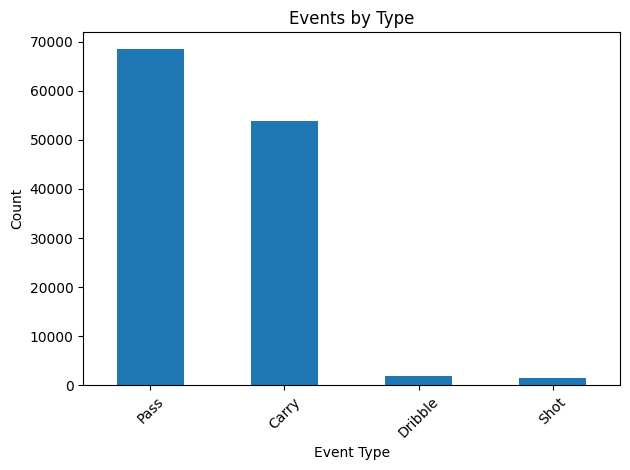

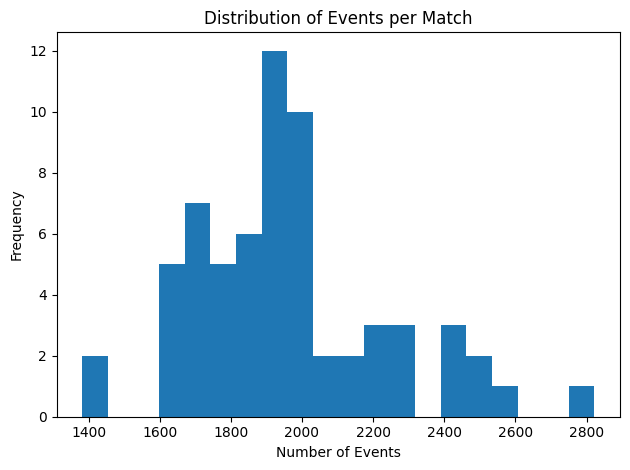

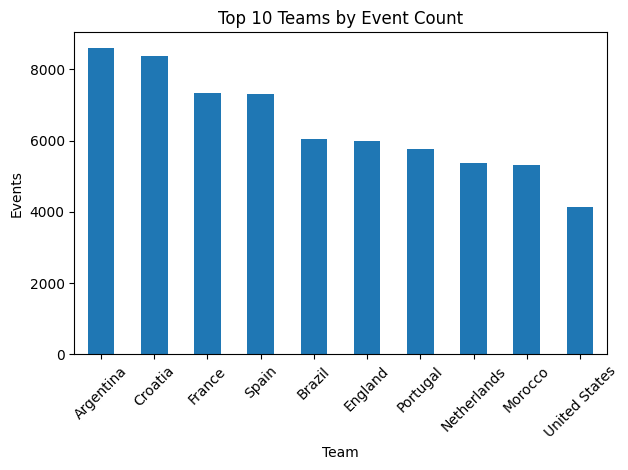

In [78]:
import matplotlib.pyplot as plt

# ===== EVENTOS POR TIPO =====
plt.figure()
events_by_type.plot(kind='bar')
plt.title("Events by Type")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ===== EVENTOS POR PARTIDO =====
plt.figure()
events_per_match.plot(kind='hist', bins=20)
plt.title("Distribution of Events per Match")
plt.xlabel("Number of Events")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ===== EVENTOS POR EQUIPO =====
plt.figure()
events_per_team.head(10).plot(kind='bar')
plt.title("Top 10 Teams by Event Count")
plt.xlabel("Team")
plt.ylabel("Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
feature_descriptions = {
    "match_id": "Identificador único del partido",
    "team.name": "Equipo que realiza la acción",
    "player.name": "Jugador que realiza la acción",
    "minute": "Minuto del evento",
    "second": "Segundo del evento",
    "possession": "Identificador de posesión",
    "x": "Coordenada X en el campo",
    "y": "Coordenada Y en el campo",
    "end_x": "Coordenada X final",
    "end_y": "Coordenada Y final",
    "type.name": "Tipo de evento (Pass, Shot, Carry, etc.)",
    "goal": "Variable objetivo (1 = gol, 0 = no gol)"
}

df_feature_desc = pd.DataFrame(list(feature_descriptions.items()), columns=['Feature', 'Description'])

print("\n=== FEATURE DESCRIPTIONS ===")
print(df_feature_desc)


=== FEATURE DESCRIPTIONS ===
        Feature                               Description
0      match_id           Identificador único del partido
1     team.name              Equipo que realiza la acción
2   player.name             Jugador que realiza la acción
3        minute                         Minuto del evento
4        second                        Segundo del evento
5    possession                 Identificador de posesión
6             x                  Coordenada X en el campo
7             y                  Coordenada Y en el campo
8         end_x                        Coordenada X final
9         end_y                        Coordenada Y final
10    type.name  Tipo de evento (Pass, Shot, Carry, etc.)
11         goal   Variable objetivo (1 = gol, 0 = no gol)


In [80]:
# Conteo de eventos por tipo
events_by_type = df_all['type.name'].value_counts()

# Crear dataframe
df_events_type = events_by_type.reset_index()
df_events_type.columns = ['Event Type', 'Count']